In [1]:
import pandas as pd

X_train = pd.read_csv("/content/x_train.csv")
X_test = pd.read_csv("/content/x_test.csv")
y_train = pd.read_csv("/content/y_train.csv")
y_test = pd.read_csv("/content/y_test.csv")


In [2]:
X_train = X_train.drop(columns=['Date'])
X_test = X_test.drop(columns=['Date'])


In [3]:
X_train = X_train.drop(columns=['Primary Type'])
X_test = X_test.drop(columns=['Primary Type'])


In [4]:
# Convert boolean columns to integer (0 or 1)
X_train['Season_Spring'] = X_train['Season_Spring'].astype(int)
X_train['Season_Summer'] = X_train['Season_Summer'].astype(int)
X_train['Season_Winter'] = X_train['Season_Winter'].astype(int)

# Similarly for X_test
X_test['Season_Spring'] = X_test['Season_Spring'].astype(int)
X_test['Season_Summer'] = X_test['Season_Summer'].astype(int)
X_test['Season_Winter'] = X_test['Season_Winter'].astype(int)


In [5]:
import numpy as np

# Reshape X_train and X_test to 3D for LSTM/GRU (samples, time_steps, features)
X_train_reshaped = np.expand_dims(X_train.values, axis=1)  # Add a dummy time step
X_test_reshaped = np.expand_dims(X_test.values, axis=1)


In [7]:
from keras.utils import to_categorical

# One-hot encode the target labels for multiclass classification
y_train_encoded = to_categorical(y_train, num_classes=10)  # Adjust num_classes as per your labels
y_test_encoded = to_categorical(y_test, num_classes=10)


In [8]:
from keras.models import Model
from keras.layers import Input, Bidirectional, LSTM, GRU, Dense, Dropout, Attention, LayerNormalization, Concatenate, Flatten
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Input Layer
input_layer = Input(shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2]))

# Bi-LSTM Layer
x = Bidirectional(LSTM(128, return_sequences=True))(input_layer)
x = LayerNormalization()(x)
x = Dropout(0.3)(x)

# GRU Layer
x = GRU(128, return_sequences=True)(x)
x = LayerNormalization()(x)
x = Dropout(0.3)(x)

# Self-Attention Layer
attn_out = Attention(use_scale=True)([x, x])  # Q=K=V=x (self-attention)
x = Concatenate()([x, attn_out])  # Combine original and attention output

# Dense + Flatten Layer
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Flatten()(x)  # Flatten before passing to the final Dense layer

# Output Layer
output_layer = Dense(10, activation='softmax')(x)  # 10 classes for multiclass classification

# Build Model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks for early stopping and learning rate scheduling
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

# Train the Model
history = model.fit(
    X_train_reshaped, y_train_encoded,
    validation_data=(X_test_reshaped, y_test_encoded),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


6807/6807 ━━━━━━━━━━━━━━━━━━━━ 72s 10ms/step - accuracy: 0.2591 - loss: 1.9953 - val_accuracy: 0.5294 - val_loss: 1.2265 - learning_rate: 1.0000e-04
Epoch 2/100
6807/6807 ━━━━━━━━━━━━━━━━━━━━ 65s 10ms/step - accuracy: 0.4759 - loss: 1.3712 - val_accuracy: 0.5767 - val_loss: 1.0506 - learning_rate: 1.0000e-04
Epoch 3/100
6807/6807 ━━━━━━━━━━━━━━━━━━━━ 66s 10ms/step - accuracy: 0.5478 - loss: 1.1831 - val_accuracy: 0.6763 - val_loss: 0.9004 - learning_rate: 1.0000e-04
Epoch 4/100
6807/6807 ━━━━━━━━━━━━━━━━━━━━ 65s 10ms/step - accuracy: 0.6042 - loss: 1.0604 - val_accuracy: 0.7304 - val_loss: 0.8138 - learning_rate: 1.0000e-04
Epoch 5/100
6807/6807 ━━━━━━━━━━━━━━━━━━━━ 66s 10ms/step - accuracy: 0.6414 - loss: 0.9826 - val_accuracy: 0.7049 - val_loss: 0.7979 - learning_rate: 1.0000e-04
Epoch 6/100
6807/6807 ━━━━━━━━━━━━━━━━━━━━ 65s 10ms/step - accuracy: 0.6698 - loss: 0.9182 - val_accuracy: 0.7070 - val_loss: 0.7516 - learning_rate: 1.0000e-04
Epoch 7/100
6807/6807 ━━━━━━━━━━━━━━━━━━━━ 66s

In [9]:
train_loss, train_acc = model.evaluate(X_train_reshaped, y_train_encoded, verbose=0)
test_loss, test_acc = model.evaluate(X_test_reshaped, y_test_encoded, verbose=0)

print(f"Train Accuracy: {train_acc:.4f}, Train Loss: {train_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")


Train Accuracy: 0.8003, Train Loss: 0.5194
Test Accuracy: 0.8032, Test Loss: 0.5172


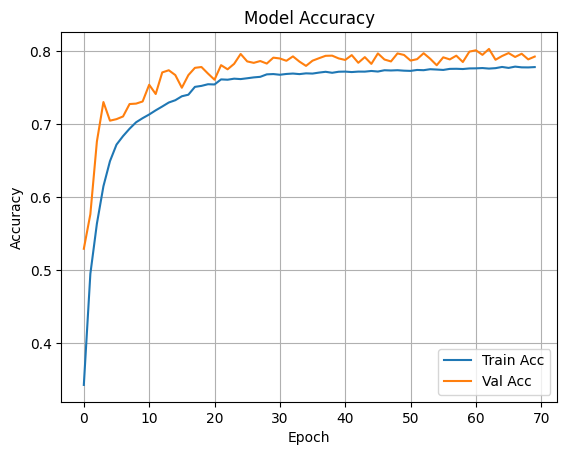

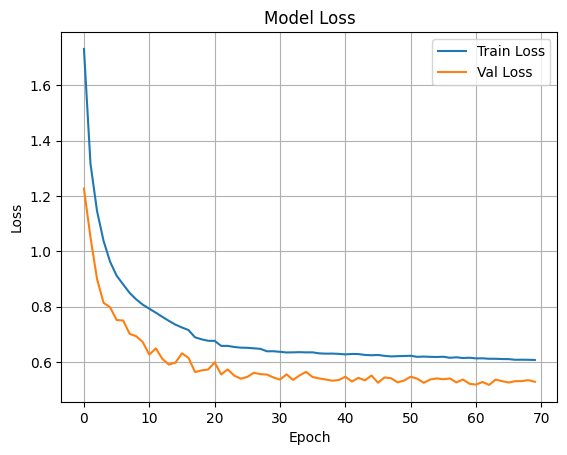

In [10]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss Plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [11]:
from sklearn.metrics import classification_report
import numpy as np

# Convert predictions & true labels from one-hot to class indices
y_train_pred = np.argmax(model.predict(X_train_reshaped), axis=1)
y_train_true = np.argmax(y_train_encoded, axis=1)

y_test_pred = np.argmax(model.predict(X_test_reshaped), axis=1)
y_test_true = np.argmax(y_test_encoded, axis=1)

# Report
print("Train Classification Report:")
print(classification_report(y_train_true, y_train_pred))

print("\nTest Classification Report:")
print(classification_report(y_test_true, y_test_pred))


/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


6807/6807 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step
1702/1702 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Train Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.72      0.67     18373
           1       0.80      0.81      0.80     34165
           2       0.90      0.60      0.72      9729
           3       0.74      0.88      0.80     19929
           4       0.88      0.82      0.85     23074
           5       0.84      0.88      0.86     30311
           6       0.79      0.75      0.77     19882
           7       0.83      0.88      0.85     18706
           8       0.85      0.80      0.82     23593
           9       0.81      0.73      0.77     20049

    accuracy                           0.80    217811
   macro avg       0.81      0.79      0.79    217811
weighted avg       0.81      0.80      0.80    217811


Test Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.73      0.

In [12]:
from sklearn.metrics import classification_report

print("Test Classification Report:")
print(classification_report(y_test_true, y_test_pred, digits=4))


Test Classification Report:
              precision    recall  f1-score   support

           0     0.6367    0.7268    0.6787      4593
           1     0.7982    0.8015    0.7999      8541
           2     0.9109    0.6053    0.7273      2432
           3     0.7379    0.8768    0.8014      4983
           4     0.8837    0.8204    0.8509      5769
           5     0.8424    0.8818    0.8616      7578
           6     0.7900    0.7501    0.7695      4970
           7     0.8264    0.8805    0.8526      4677
           8     0.8541    0.8101    0.8315      5898
           9     0.8143    0.7330    0.7715      5012

    accuracy                         0.8032     54453
   macro avg     0.8095    0.7886    0.7945     54453
weighted avg     0.8085    0.8032    0.8031     54453



1702/1702 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


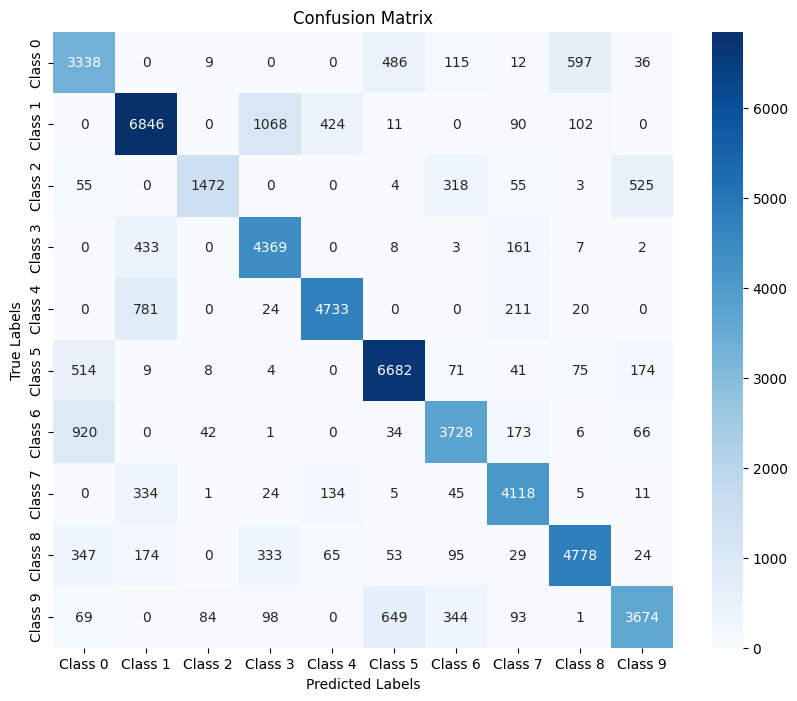

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Define class names (you can replace this with your actual class names if needed)
class_names = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5', 'Class 6', 'Class 7', 'Class 8', 'Class 9']

# Predict on the test set
y_pred = model.predict(X_test_reshaped)

# Convert predictions from probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert y_test from one-hot encoding to class labels
y_test_classes = np.argmax(y_test_encoded, axis=1)

# Generate confusion matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


In [13]:
import numpy as np

# Predict probabilities
y_pred_probs = model.predict(X_test_reshaped)

# Get predicted class labels
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_test_encoded, axis=1)

# View first 10 predictions vs actual
for i in range(10):
    print(f"True: {y_true_labels[i]} | Predicted: {y_pred_labels[i]}")


1702/1702 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
True: 6 | Predicted: 6
True: 9 | Predicted: 9
True: 0 | Predicted: 0
True: 4 | Predicted: 4
True: 1 | Predicted: 1
True: 9 | Predicted: 9
True: 5 | Predicted: 5
True: 0 | Predicted: 0
True: 1 | Predicted: 1
True: 9 | Predicted: 9


In [16]:
# Save the model in the native Keras format
model.save(r"C:\Users\atuly\Desktop\CRIME_PRED_PROJECT\bilstm_gru_attention_model.keras")


In [17]:
from keras.models import load_model

# Load the model from the native Keras format
model = load_model(r"C:\Users\atuly\Desktop\CRIME_PRED_PROJECT\bilstm_gru_attention_model.keras")


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 20 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
